# Chapter7. 양자 커널을 이용한 지도학습(Quantum Kernel Supervised Learning)

## 개요(Overview)

머신 러닝의 일반적인 작업은 데이터의 패턴을 찾고 연구하는 것이다. 많은 데이터셋의 경우, 데이터 포인트는 기존의 고전적인 기법을 사용하여 효과적으로 분류하거나 군집화할 수 없다. 양자 커널을 사용하면 고전적으로 분류하기 어려운 데이터를 분리할 수 있는 고차원 특성 공간에 매핑할 수 있다.

이 노트북에서는 양자 커널을 사용한 **지도학습(분류)** 워크플로우를 다룬다.

**내용:**

1. [소개](#1.-소개(Introduction))
2. [분류](#2.-분류(Classification))
3. [결론](#3.-결론(Conclusion))

비지도학습(군집화, 커널 PCA)은 `ch08_quantum_kernel_unsupervised.ipynb`에서 다룬다.


## 1. 소개(Introduction)

### 1.1. 머신 러닝을 위한 커널 방법(Kernel Methods for Machine Learning)

커널 방법은 커널 함수를 사용하여 고차원 특성(Feature) 공간에서 작동하는 패턴 분석 알고리즘의 모음이다. 커널 방법의 가장 잘 알려진 응용은 분류(Classification) 작업에 일반적으로 사용되는 지도 학습 알고리즘인 **서포트 벡터 머신(Support Vector Machines, SVMs)**이다. SVMs의 주요 목표는 주어진 데이터 포인트 세트를 클래스로 분리하는 결정 경계(Decision Boundaries)를 찾는 것이다. 이러한 데이터 공간이 선형적으로 분리 가능하지 않을 때, SVMs은 이러한 경계를 찾기 위해 커널의 사용으로부터 이점을 얻을 수 있다.

형식적으로, 결정 경계는 고차원 공간의 초평면(Hyperplanes)이다. 커널 함수는 입력 데이터를 이 더 높은 차원의 공간으로 암묵적으로 매핑하며, 여기서 초기 문제를 해결하기가 더 쉬울 수 있다. 다시 말해, 커널은 원래 선형적으로 분리할 수 없는 데이터 분포를 선형적으로 분리 가능한 문제로 만들 수 있다. 이는 "커널 트릭(Kernel Trick)"으로 알려진 효과이다.

커널 기반 비지도(Unsupervised) 알고리즘에 대한 사용 사례도 있다. 예를 들어, 군집화(Clustering)의 맥락에서 **스펙트럼 클러스터링(Spectral Clustering)**은 데이터 포인트를 그래프의 노드로 취급하고, 군집화 작업을 노드를 매핑하여 클러스터를 형성하기 쉬운 공간으로 변환하는 그래프 분할 문제로 보는 기법이다.

### 1.2. 커널 함수(Kernel Functions)

수학적으로, 커널 함수는 다음과 같다:

$k(\vec{x}_i, \vec{x}_j) = \langle f(\vec{x}_i), f(\vec{x}_j) \rangle$

여기서
* $k$는 커널 함수
* $\vec{x}_i, \vec{x}_j$는 $n$ 차원 입력
* $f$는 $n$-차원에서 $m$-차원 공간으로의 매핑이고
* $\langle a,b \rangle$는 내적(Inner Product)을 나타낸다.

유한 데이터를 고려할 때, 커널 함수는 행렬로 표현될 수 있다:

$K_{ij} = k(\vec{x}_i,\vec{x}_j)$.

### 1.3. 양자 커널(Quantum Kernels)

양자 커널 머신 러닝 뒤의 주요 아이디어는 커널 트릭을 수행하기 위해 양자 특성 맵(Quantum Feature Maps)을 활용하는 것이다. 이 경우, 양자 커널은 양자 특성 맵 $\phi(\vec{x})$를 사용하여 고전 특성 벡터(Classical Feature Vector) $\vec{x}$를 힐베르트 공간(Hilbert Space)에 매핑함으로써 생성된다. 수학적으로:

$K_{ij} = \left| \langle \phi(\vec{x}_i)| \phi(\vec{x}_j) \rangle \right|^{2}$

여기서
* $K_{ij}$는 커널 행렬
* $\vec{x}_i, \vec{x}_j$는 $n$ 차원 입력
* $\phi(\vec{x})$는 양자 특성 맵이고
* $\left| \langle a|b \rangle \right|^{2}$는 두 양자 상태 $a$와 $b$의 겹침(Overlap)을 나타낸다.

양자 커널은 SVMs 또는 군집화 알고리즘과 같은 일반적인 고전 커널 학습 알고리즘에 연결될 수 있으며, 아래의 예제에서 볼 수 있듯이, 이 튜토리얼에서 탐색되는 [QSVC](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html) 클래스와 같은 새로운 양자 커널 방법에서도 활용될 수 있다. 그리고 [Pegasos QSVC](07_pegasos_qsvc.ipynb)와 [Quantum Kernel Training](08_quantum_kernel_trainer.ipynb)에 대한 나중의 튜토리얼에 나와 있는 다른 방법들이 있다.

***

어떤 예제를 소개하기 전에, 재현성을 보장하기 위해 전역 시드(Global Seed)를 설정한다:

In [1]:
# 재현성을 위해 알고리즘 전역 시드를 설정한다(Set algorithm global seed for reproducibility)
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 12345

## 2. 분류(Classification)

이 섹션은 `qiskit-machine-learning`을 사용한 양자 커널 분류 워크플로우를 보여준다.

### 2.1. 데이터셋 정의하기(Defining the dataset)

이 예제의 경우, 참고 [논문](https://arxiv.org/pdf/1804.11326.pdf)에 설명된 _애드혹 데이터셋(Ad Hoc Dataset)_을 사용한다.

데이터셋 차원을 정의하고 학습 및 테스트 부분집합을 얻을 수 있다:

In [2]:
# 애드혹 데이터셋을 로드한다(Load ad hoc dataset)
from qiskit_machine_learning.datasets import ad_hoc_data

adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=20,
    test_size=5,
    n=adhoc_dimension,
    gap=0.3,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

이 데이터셋은 2차원이며, 두 특성은 $x$와 $y$ 좌표로 표현되고, 두 개의 클래스 라벨이 있다: A와 B. 우리는 이를 그래프로 그려보고 분포가 어떻게 보이는지 확인할 수 있다. 데이터셋을 그리기 위한 유틸리티 함수를 정의한다.

In [3]:
# 데이터셋을 플롯하기 위한 유틸리티 함수들을 정의한다(Define utility functions to plot the dataset)
import matplotlib.pyplot as plt
import numpy as np


def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )


def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):

    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )

    # A train plot
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A train")

    # B train plot
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B train")

    # A test plot
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")

    # B test plot
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Ad hoc dataset")

    plt.show()

이제 실제로 분류를 위한 데이터셋을 그린다:

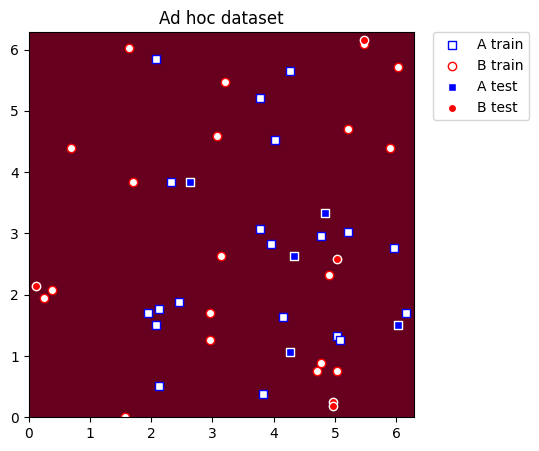

In [4]:
# 분류를 위한 데이터셋을 플롯한다(Plot the dataset for classification)
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

### 2.2. 양자 커널 정의하기(Defining the quantum kernel)

다음 단계는 이 데이터를 분류하는 데 도움이 될 양자 커널 인스턴스를 생성하는 것이다.

우리는 [FidelityQuantumKernel](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html) 클래스를 사용하고 생성자에 두 개의 입력 인자를 전달한다:

1. `feature_map`: 이 경우, 두 개의 큐비트(Qubit) [zz_feature_map](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map).

2. `fidelity`: 이 경우, [Sampler](https://quantum.cloud.ibm.com/docs/api/qiskit/1.4/qiskit.primitives.Sampler) 프리미티브(Primitive)를 활용하는 [ComputeUncompute](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.state_fidelities.ComputeUncompute.html) 충실도(Fidelity) 서브루틴.

**주의:** `Sampler` 또는 `Fidelity` 인스턴스를 전달하지 않으면, 참조 `Sampler` 및 `ComputeUncompute` 클래스의 인스턴스(`qiskit.primitives`에서 찾음)가 기본적으로 생성된다.

In [5]:
# 양자 커널을 정의한다(Define the quantum kernel)
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

adhoc_feature_map = zz_feature_map(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")

sampler = Sampler()

fidelity = ComputeUncompute(sampler=sampler)

adhoc_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=adhoc_feature_map)

### 2.3. SVC를 사용한 분류(Classification with SVC)

양자 커널은 이제 `scikit-learn`의 [SVC](https://scikit-learn.org/stable/modules/svm.html) 알고리즘과 같은 고전 커널 방법에 연결될 수 있다. 이 알고리즘은 두 가지 방식으로 [커스텀 커널](https://scikit-learn.org/stable/modules/svm.html#custom-kernels)을 정의할 수 있다:

1. **호출 가능한 함수(Callable Function)**로 커널을 제공하여
2. **커널 행렬(Kernel Matrix)**을 사전 계산하여

#### 호출 가능한 함수로서의 커널(Kernel as a callable function)

우리는 SVC 모델을 정의하고 양자 커널의 `evaluate` 함수를 호출 가능한 것으로 직접 전달한다. 모델이 생성되면, 학습 데이터셋에서 `fit` 메서드를 호출하여 훈련하고 `score`로 정확도를 평가한다.

In [6]:
# SVC를 사용하여 호출 가능한 함수로 양자 커널을 적용한다(Apply quantum kernel as callable function with SVC)
from sklearn.svm import SVC

adhoc_svc = SVC(kernel=adhoc_kernel.evaluate)

adhoc_svc.fit(train_features, train_labels)

adhoc_score_callable_function = adhoc_svc.score(test_features, test_labels)

print(f"Callable kernel classification test score: {adhoc_score_callable_function}")

Callable kernel classification test score: 1.0


#### 사전 계산된 커널 행렬(Precomputed kernel matrix)

양자 커널의 함수를 호출 가능한 것으로 전달하는 대신, 우리는 또한 `scikit-learn` `SVC` 알고리즘에 전달하기 전에 학습 및 테스트 커널 행렬을 사전 계산할 수 있다.

학습 및 테스트 행렬을 추출하기 위해, 우리는 이전에 정의된 커널에서 `evaluate`를 호출할 수 있고 다음과 같이 그래프로 시각화할 수 있다:

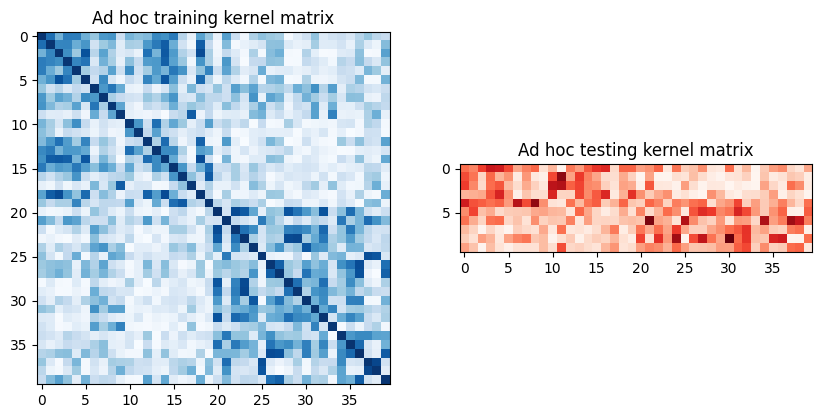

In [7]:
# 학습 및 테스트 커널 행렬을 평가하고 시각화한다(Evaluate and visualize training and test kernel matrices)
adhoc_matrix_train = adhoc_kernel.evaluate(x_vec=train_features)
adhoc_matrix_test = adhoc_kernel.evaluate(x_vec=test_features, y_vec=train_features)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(
    np.asmatrix(adhoc_matrix_train), interpolation="nearest", origin="upper", cmap="Blues"
)
axs[0].set_title("Ad hoc training kernel matrix")

axs[1].imshow(np.asmatrix(adhoc_matrix_test), interpolation="nearest", origin="upper", cmap="Reds")
axs[1].set_title("Ad hoc testing kernel matrix")

plt.show()

이러한 행렬을 사용하려면, 새로운 `SVC` 인스턴스의 `kernel` 파라미터를 `"precomputed"`로 설정한다. 학습 행렬 및 학습 데이터셋으로 `fit`을 호출하여 분류기를 훈련한다. 모델이 훈련되면, 테스트 행렬을 사용하여 테스트 데이터셋에서 평가한다.

In [8]:
# 사전 계산된 커널 행렬을 사용하여 SVC를 적합시킨다(Fit SVC with precomputed kernel matrix)
adhoc_svc = SVC(kernel="precomputed")

adhoc_svc.fit(adhoc_matrix_train, train_labels)

adhoc_score_precomputed_kernel = adhoc_svc.score(adhoc_matrix_test, test_labels)

print(f"Precomputed kernel classification test score: {adhoc_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


### 2.4. QSVC를 사용한 분류(Classification with QSVC)

`QSVC`는 편의를 위해 `qiskit-machine-learning`이 제공하는 대체 학습 알고리즘이다. 이는 이전에 표시된 `kernel.evaluate` 메서드 대신 양자 커널을 취하는 `SVC`의 확장이다.

In [9]:
# QSVC를 사용하여 분류기를 훈련한다(Train classifier using QSVC)
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=adhoc_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC classification test score: {qsvc_score}")

QSVC classification test score: 1.0


### 2.5. 분류에 사용된 모델 평가(Evaluation of models used for classification)

In [10]:
# 분류 모델들의 정확도를 출력한다(Print accuracy scores of classification models)
print(f"Classification Model                    | Accuracy Score")
print(f"---------------------------------------------------------")
print(f"SVC using kernel as a callable function | {adhoc_score_callable_function:10.2f}")
print(f"SVC using precomputed kernel matrix     | {adhoc_score_precomputed_kernel:10.2f}")
print(f"QSVC                                    | {qsvc_score:10.2f}")

Classification Model                    | Accuracy Score
---------------------------------------------------------
SVC using kernel as a callable function |       1.00
SVC using precomputed kernel matrix     |       1.00
QSVC                                    |       1.00


분류 데이터셋이 작기 때문에, 우리는 세 모델 모두 100% 정확도를 달성함을 발견한다.

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright